<a href="https://colab.research.google.com/github/Pedro4Albuquerque/am-t4-s1a2026t2/blob/main/MultiNeuralCredit0609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Random Florest | Digest [Fase 1 - credit_data]

## Importar dados do Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_credit

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/am-t4/credit.pkt', 'rb') as f:
  X_credit_treinamento, Y_credit_treinamento, X_credit_teste, Y_credit_teste = pickle.load(f)

In [6]:
X_credit_treinamento.shape, Y_credit_treinamento.shape

((1700, 3), (1700,))

In [7]:
X_credit_teste.shape, Y_credit_teste.shape

((300, 3), (300,))

In [8]:
from sklearn.ensemble import RandomForestClassifier

In [9]:
random_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
random_credit.fit(X_credit_treinamento, Y_credit_treinamento)
RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='entropy', max_depth=None, max_features='auto',
                       min_impurity_decrease=0.0, min_samples_split=None,
                       min_samples_leaf=1, min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=0,verbose=0,warm_start=False)

RandomForestClassifier(criterion='entropy', max_features='auto',
                       min_samples_split=None, n_estimators=10, random_state=0)

In [10]:
previsores_random = random_credit.predict(X_credit_teste)

In [11]:
previsores_random

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

## Criando base Previsora

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [13]:
accuracy_score(Y_credit_teste, previsores_random)

0.9733333333333334

In [14]:
confusion_matrix(Y_credit_teste, previsores_random)

array([[257,   3],
       [  5,  35]])

In [15]:
from yellowbrick.classifier import ConfusionMatrix

0.9733333333333334

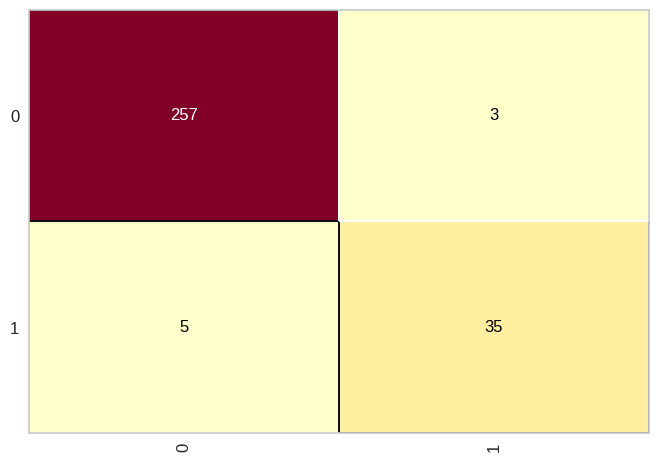

In [16]:
cm_credit_rf = ConfusionMatrix(random_credit)
cm_credit_rf.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit_rf.score(X_credit_teste, Y_credit_teste)

In [17]:
print(classification_report(Y_credit_teste, previsores_random))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       260
           1       0.92      0.88      0.90        40

    accuracy                           0.97       300
   macro avg       0.95      0.93      0.94       300
weighted avg       0.97      0.97      0.97       300



# Pipeline Regressão | Digest [Fase 1 Credit Base]

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
regressao_credit = LogisticRegression(random_state=1)
regressao_credit.fit(X_credit_treinamento, Y_credit_treinamento)

LogisticRegression(random_state=1)

In [20]:
LogisticRegression(C=1.0,class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty ='l2',
                   random_state=1, solver='lbfgs', tol =0.0001, verbose=0,
                   warm_start=False)

LogisticRegression(multi_class='auto', random_state=1)

In [21]:
regressao_previsoes = regressao_credit.predict(X_credit_teste)
regressao_previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [22]:
accuracy_score(Y_credit_teste, regressao_credit.predict(X_credit_teste))

0.9533333333333334

In [23]:
from yellowbrick.classifier import ConfusionMatrix

0.9533333333333334

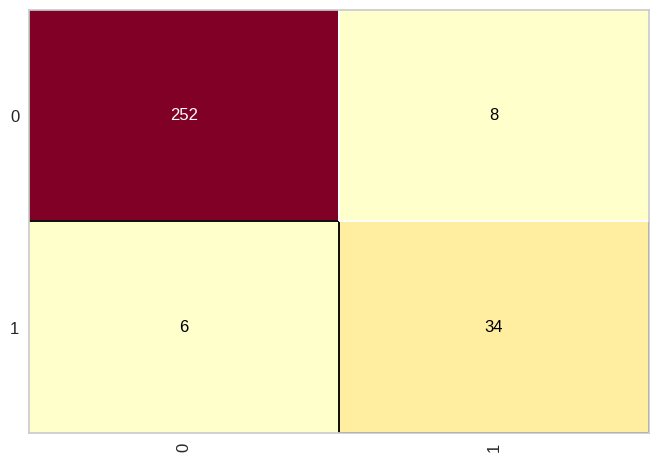

In [24]:
cm_credit_reg = ConfusionMatrix(regressao_credit)
cm_credit_reg.fit(X_credit_treinamento, Y_credit_treinamento)
cm_credit_reg.score(X_credit_teste, Y_credit_teste)

In [25]:
print(classification_report(Y_credit_teste, regressao_credit.predict(X_credit_teste)))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       260
           1       0.81      0.85      0.83        40

    accuracy                           0.95       300
   macro avg       0.89      0.91      0.90       300
weighted avg       0.95      0.95      0.95       300



# Pipeline SVM | Digest [Fase 1 Credit Base]

In [26]:
from sklearn.svm import SVC

In [27]:
svm_credit = SVC(kernel='rbf', random_state=1, C=2.0)
svm_credit.fit(X_credit_treinamento, Y_credit_treinamento)

SVC(C=2.0, random_state=1)

In [28]:
SVC(C=2.0,break_ties=False,cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='rbf',
    max_iter=-1, probability=False, random_state=1, shrinking=True, tol=0.001,
    verbose = False)

SVC(C=2.0, random_state=1)

In [29]:
svm_previsoes = svm_credit.predict(X_credit_teste)
svm_previsoes

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [30]:
accuracy_score(Y_credit_teste, svm_credit.predict(X_credit_teste))

0.9933333333333333

0.9933333333333333

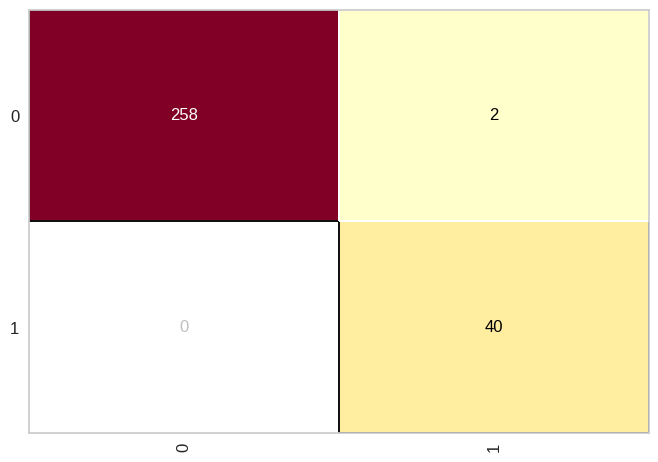

In [31]:
svm_credit_cm = ConfusionMatrix(svm_credit)
svm_credit_cm.fit(X_credit_treinamento, Y_credit_treinamento)
svm_credit_cm.score(X_credit_teste, Y_credit_teste)

In [32]:
print(classification_report(Y_credit_teste, svm_credit.predict(X_credit_teste)))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       260
           1       0.95      1.00      0.98        40

    accuracy                           0.99       300
   macro avg       0.98      1.00      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline Redes Neurais | Digest [ Fase 1 Credit Base ]

In [33]:
from sklearn.neural_network import MLPClassifier

In [34]:
redeneural_credit = MLPClassifier(verbose=True, max_iter=1000, tol=0.000010, solver='adam',
                                  hidden_layer_sizes=(100), activation='relu')
redeneural_credit.fit(X_credit_treinamento, Y_credit_treinamento)


Iteration 1, loss = 0.69792332
Iteration 2, loss = 0.61708457
Iteration 3, loss = 0.55101608
Iteration 4, loss = 0.49605505
Iteration 5, loss = 0.45055917
Iteration 6, loss = 0.41236710
Iteration 7, loss = 0.38028340
Iteration 8, loss = 0.35259753
Iteration 9, loss = 0.32853641
Iteration 10, loss = 0.30760888
Iteration 11, loss = 0.28887903
Iteration 12, loss = 0.27231540
Iteration 13, loss = 0.25744757
Iteration 14, loss = 0.24389108
Iteration 15, loss = 0.23159033
Iteration 16, loss = 0.22044543
Iteration 17, loss = 0.21026245
Iteration 18, loss = 0.20102658
Iteration 19, loss = 0.19234580
Iteration 20, loss = 0.18454161
Iteration 21, loss = 0.17743341
Iteration 22, loss = 0.17074299
Iteration 23, loss = 0.16460215
Iteration 24, loss = 0.15899994
Iteration 25, loss = 0.15385001
Iteration 26, loss = 0.14911273
Iteration 27, loss = 0.14466775
Iteration 28, loss = 0.14057597
Iteration 29, loss = 0.13672784
Iteration 30, loss = 0.13314606
Iteration 31, loss = 0.12973875
Iteration 32, los

MLPClassifier(hidden_layer_sizes=100, max_iter=1000, tol=1e-05, verbose=True)

In [35]:
redeneural_credit.out_activation_

'logistic'

In [36]:
previsores_randeural = redeneural_credit.predict(X_credit_teste)
previsores_randeural

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [37]:
accuracy_score(Y_credit_teste, redeneural_credit.predict(X_credit_teste))
#

0.9933333333333333

0.9933333333333333

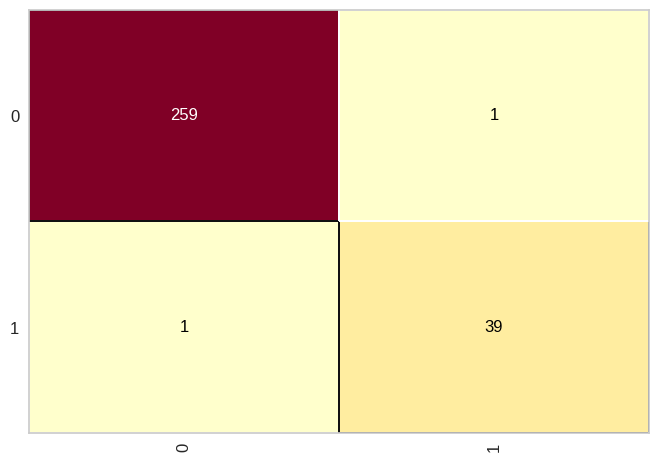

In [38]:
rn_cm= ConfusionMatrix(redeneural_credit)
rn_cm.fit(X_credit_treinamento, Y_credit_treinamento)
rn_cm.score(X_credit_teste, Y_credit_teste)

In [39]:
print(classification_report(Y_credit_teste, redeneural_credit.predict(X_credit_teste)))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       260
           1       0.97      0.97      0.97        40

    accuracy                           0.99       300
   macro avg       0.99      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300



# Pipeline de Preparação dos Dados | Credit_Base [Fase 1 Base Credit]

In [42]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [43]:
parametros = {'n_neighbors': [3, 5, 10, 20],
              'p': [1, 2]}

In [46]:
grid_credit = GridSearchCV(estimator=KNeighborsClassifier(), param_grid=parametros)
grid_credit.fit(X_credit_treinamento, Y_credit_treinamento)
melhor_paremetro_credit = grid_credit.best_params_
melhor_resultado_credit = grid_credit.best_score_
print(melhor_paremetro_credit)
print(melhor_resultado_credit)

{'n_neighbors': 5, 'p': 2}
0.9823529411764707


##